<a href="https://colab.research.google.com/github/PranjanaNarayan/fraud-detection-system/blob/main/fraud_detection_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

df = pd.read_csv("/content/creditcard.csv")
print("\nShape:", df.shape)
print("Data loaded successfully!")

NumPy: 2.0.2
Pandas: 2.2.2

Shape: (284807, 31)
Data loaded successfully!


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Clean missing values
df = df.dropna()
print("Shape after cleaning:", df.shape)

# Scale columns
scaler = StandardScaler()
df = df.copy()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df = df.drop(['Amount', 'Time'], axis=1)

# Split
X = df.drop('Class', axis=1)
y = df['Class'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Fraud cases in train:", y_train.sum())
print("Done!")

Shape after cleaning: (284807, 31)
Train size: (227845, 30)
Test size: (56962, 30)
Fraud cases in train: 394
Done!


In [14]:
!pip install imbalanced-learn shap -q
print("All packages ready!")

All packages ready!


In [15]:
!pip install imbalanced-learn shap xgboost -q
print("All packages installed!")

All packages installed!


In [16]:
import pandas as pd

df = pd.read_csv("/content/creditcard.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


Shape: (284807, 31)

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


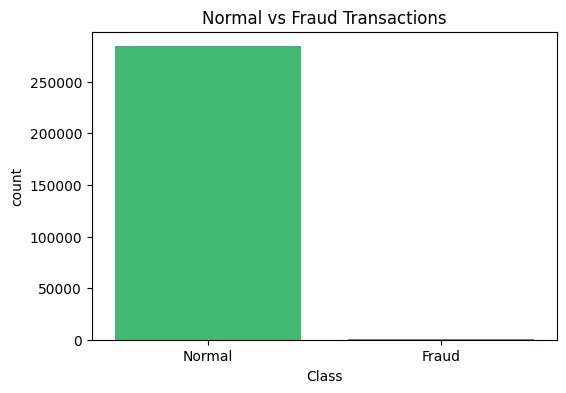

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Shape:", df.shape)
print("\nClass Distribution:")
print(df['Class'].value_counts())

fraud_pct = df['Class'].value_counts()[1] / len(df) * 100
print(f"\nFraud percentage: {fraud_pct:.4f}%")

plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Normal vs Fraud Transactions')
plt.xticks([0,1], ['Normal', 'Fraud'])
plt.show()

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("/content/creditcard.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Missing values:", df.isnull().sum().sum())

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Missing values: 0


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = df.dropna()
print("Shape after cleaning:", df.shape)

scaler = StandardScaler()
df = df.copy()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])
df = df.drop(['Amount', 'Time'], axis=1)

X = df.drop('Class', axis=1)
y = df['Class'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Fraud in train:", y_train.sum())
print("Done!")

Shape after cleaning: (284807, 31)
Train size: (227845, 30)
Test size: (56962, 30)
Fraud in train: 394
Done!


In [21]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print("Normal:", (y_train==0).sum())
print("Fraud:", (y_train==1).sum())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print("Normal:", (y_train_smote==0).sum())
print("Fraud:", (y_train_smote==1).sum())
print("Both classes balanced!")

Before SMOTE:
Normal: 227451
Fraud: 394

After SMOTE:
Normal: 227451
Fraud: 227451
Both classes balanced!


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("Training Logistic Regression...")
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_smote, y_train_smote)
lr_pred = lr.predict(X_test)
print("Done!")

print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_smote, y_train_smote)
rf_pred = rf.predict(X_test)
print("Done!")

print("Training XGBoost...")
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_smote, y_train_smote)
xgb_pred = xgb.predict(X_test)
print("All 3 models trained!")

Training Logistic Regression...
Done!
Training Random Forest...
Done!
Training XGBoost...
All 3 models trained!


In [25]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

def evaluate_model(name, y_test, y_pred, model, X_test):
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
          target_names=['Normal', 'Fraud']))
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    print(f"ROC-AUC Score: {auc:.4f}")
    cm = confusion_matrix(y_test, y_pred)
    print(f"Fraud Caught:  {cm[1][1]}")
    print(f"Fraud Missed:  {cm[1][0]}")

evaluate_model("Logistic Regression", y_test, lr_pred, lr, X_test)
evaluate_model("Random Forest", y_test, rf_pred, rf, X_test)
evaluate_model("XGBoost", y_test, xgb_pred, xgb, X_test)


Model: Logistic Regression
              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962

ROC-AUC Score: 0.9698
Fraud Caught:  90
Fraud Missed:  8

Model: Random Forest
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.81      0.81      0.81        98

    accuracy                           1.00     56962
   macro avg       0.91      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC Score: 0.9688
Fraud Caught:  79
Fraud Missed:  19

Model: XGBoost
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.73      0.89      0.80        98

 

Generating SHAP explanations...


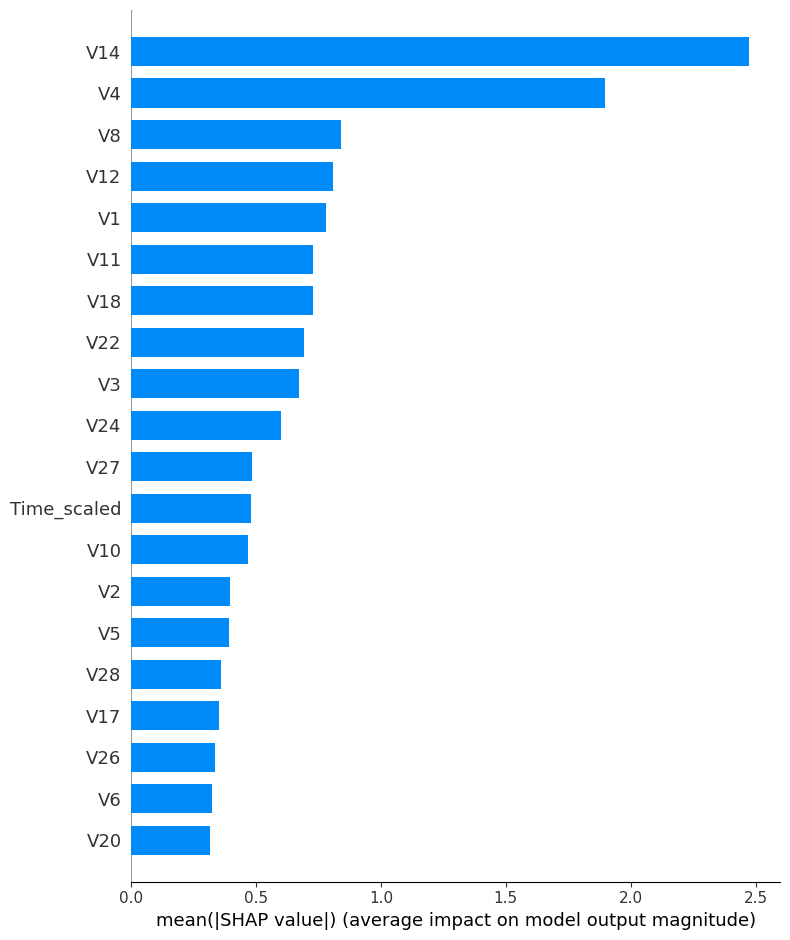

Done! This shows WHY each transaction was flagged as fraud


In [26]:
import shap

print("Generating SHAP explanations...")
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test[:100])

shap.summary_plot(shap_values, X_test[:100],
                  plot_type="bar", show=True)
print("Done! This shows WHY each transaction was flagged as fraud")

In [27]:
import pickle
from google.colab import files

save_data = {
    'model': xgb,
    'scaler': scaler,
    'feature_names': X.columns.tolist()
}

with open('fraud_model.pkl', 'wb') as f:
    pickle.dump(save_data, f)

files.download('fraud_model.pkl')
print("Model saved and downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model saved and downloaded!
